In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ananthu017_emotion_detection_fer_path = kagglehub.dataset_download('ananthu017/emotion-detection-fer')

print('Data source import complete.')


Using Colab cache for faster access to the 'emotion-detection-fer' dataset.
Data source import complete.


In [ ]:
import kagglehub
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

Using Colab cache for faster access to the 'emotion-detection-fer' dataset.


# Importing the library

In [ ]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Loading the dataset

In [ ]:
Train_data = tf.keras.utils.image_dataset_from_directory(
    directory=path,
    labels='inferred',
    label_mode='int',
    image_size=(256, 256),
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

Found 35887 files belonging to 2 classes.


In [ ]:
Test_data = tf.keras.utils.image_dataset_from_directory(
    directory=path,
    labels='inferred',
    label_mode='int',
    image_size=(256, 256),
    interpolation='nearest',
    batch_size=32,
    shuffle=False # Usually shuffle is not needed for test data
)

Found 35887 files belonging to 2 classes.


In [ ]:
class_name = Train_data.class_names
class_name

['test', 'train']

In [ ]:
len(Train_data )

1122

In [ ]:
len(Test_data)

1122

# Checking the Size Of Image

In [ ]:
for image_batch,label_batch in Train_data .take(1):
  print(image_batch.shape)
  print(label_batch[0].numpy())

(32, 256, 256, 3)
1


In [ ]:
for image_size,label in Train_data .take(1):
  print(image_size)

tf.Tensor(
[[[[251 251 251]
   [251 251 251]
   [251 251 251]
   ...
   [253 253 253]
   [253 253 253]
   [253 253 253]]

  [[251 251 251]
   [251 251 251]
   [251 251 251]
   ...
   [253 253 253]
   [253 253 253]
   [253 253 253]]

  [[251 251 251]
   [251 251 251]
   [251 251 251]
   ...
   [253 253 253]
   [253 253 253]
   [253 253 253]]

  ...

  [[237 237 237]
   [237 237 237]
   [237 237 237]
   ...
   [189 189 189]
   [189 189 189]
   [189 189 189]]

  [[237 237 237]
   [237 237 237]
   [237 237 237]
   ...
   [189 189 189]
   [189 189 189]
   [189 189 189]]

  [[237 237 237]
   [237 237 237]
   [237 237 237]
   ...
   [189 189 189]
   [189 189 189]
   [189 189 189]]]


 [[[ 93  93  93]
   [ 93  93  93]
   [ 93  93  93]
   ...
   [ 58  58  58]
   [ 58  58  58]
   [ 58  58  58]]

  [[ 93  93  93]
   [ 93  93  93]
   [ 93  93  93]
   ...
   [ 58  58  58]
   [ 58  58  58]
   [ 58  58  58]]

  [[ 93  93  93]
   [ 93  93  93]
   [ 93  93  93]
   ...
   [ 58  58  58]
   [ 58  58  58]


# View Image

In [ ]:
for image_batch,label in Train_data .take(1):
  plt.imshow(image_batch[0].numpy().astype('uint8'))
  plt.title(class_name[label[0]])


NameError: name 'Train_data' is not defined

# Spliting the model
test dataset will be for testing and the data veriabe converted in to train and validate data set
80% train and 20% validate

In [ ]:
len(Train_data )

1122

In [ ]:
899-718

181

# train dataSet

In [ ]:
train_size = 0.8
len(Train_data )*train_size
train_ds = Train_data .take(718)

In [ ]:
len(train_ds)

718

# Test Data Set

In [ ]:
len(Test_data)

1122

In [ ]:
test_ds = Test_data
len(test_ds)

1122

# Validate Data Set

In [ ]:
val_ds = Train_data .skip(718)
len(val_ds)
val_ds = Train_data .take(180)
len(val_ds)

180

In [ ]:
print(len(train_ds))
print(len(test_ds))
print(len(val_ds))

718
1122
180


# Shuffling the data Set

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

# Rescaling the images

In [ ]:
IMAGE_SIZE = 256
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
]
)

# Data Augmented

In [ ]:
data_augmnet = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
]
)

# CNN

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS=3
EPOCHS=50
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 7

In [ ]:
from tensorflow.keras import layers, models, regularizers

model = models.Sequential([
    # 1️⃣ Preprocessing
    resize_and_rescale,
    data_augmnet,

    # 2️⃣ Convolutional Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(256, 256, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # 3️⃣ Convolutional Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # 4️⃣ Convolutional Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # 5️⃣ Feature Extraction
    layers.GlobalAveragePooling2D(),

    # 6️⃣ Fully Connected Layers (Classifier Head)
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.build(input_shape = input_shape)

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (32, 256, 256, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (32, 256, 256, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (32, 256, 256, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (32, 256, 256, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (32, 128, 128, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 128, 128, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (32, 128, 128, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (32, 128, 128, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (32, 128, 128, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (32, 128, 128, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (32, 64, 64, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (32, 64, 64, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (32, 64, 64, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (32, 64, 64, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (32, 64, 64, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (32, 64, 64, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (32, 32, 32, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (32, 32, 32, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (32, 128)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 324,647 (1.24 MB)

 Trainable params: 323,239 (1.23 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
# model.compile(
#     optimizer='adam',
#     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
#     metrics=['accuracy']
# )


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # or 'categorical_crossentropy' if one-hot
    metrics=['accuracy']
)
EPOCHS = 4
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=32,
    verbose=1
)


Epoch 1/4
718/718 ━━━━━━━━━━━━━━━━━━━━ 368s 408ms/step - accuracy: 0.5639 - loss: 1.4935 - val_accuracy: 0.8085 - val_loss: 0.6252
Epoch 2/4
718/718 ━━━━━━━━━━━━━━━━━━━━ 281s 391ms/step - accuracy: 0.7949 - loss: 0.6519 - val_accuracy: 0.8085 - val_loss: 0.5772
Epoch 3/4
718/718 ━━━━━━━━━━━━━━━━━━━━ 281s 391ms/step - accuracy: 0.7980 - loss: 0.5879 - val_accuracy: 0.8085 - val_loss: 0.5384
Epoch 4/4
718/718 ━━━━━━━━━━━━━━━━━━━━ 280s 391ms/step - accuracy: 0.8007 - loss: 0.5528 - val_accuracy: 0.8085 - val_loss: 0.5178


In [ ]:
# history = model.fit(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     validation_data=val_ds,
#     verbose=1,
#     epochs=5,
# )

In [ ]:
scores = model.evaluate(test_ds)

1122/1122 ━━━━━━━━━━━━━━━━━━━━ 116s 63ms/step - accuracy: 0.2148 - loss: 0.8639


first image to predict
actual label: train


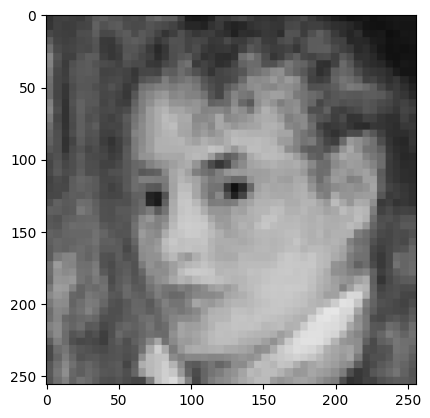

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):

    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_name[first_label])


First image actua Label: train
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
test


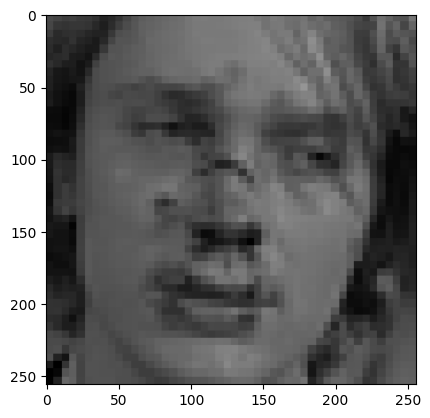

In [ ]:
  for image_batch, labels_batch in test_ds.take(1):
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()


    plt.imshow(first_image)
    print("First image actua Label:",class_name[first_label])
    batch_pre =model.predict(image_batch)
    print(class_name[np.argmax(batch_pre[0])])

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

Using Colab cache for faster access to the 'emotion-detection-fer' dataset.
Found 35887 files belonging to 2 classes.
Found 35887 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


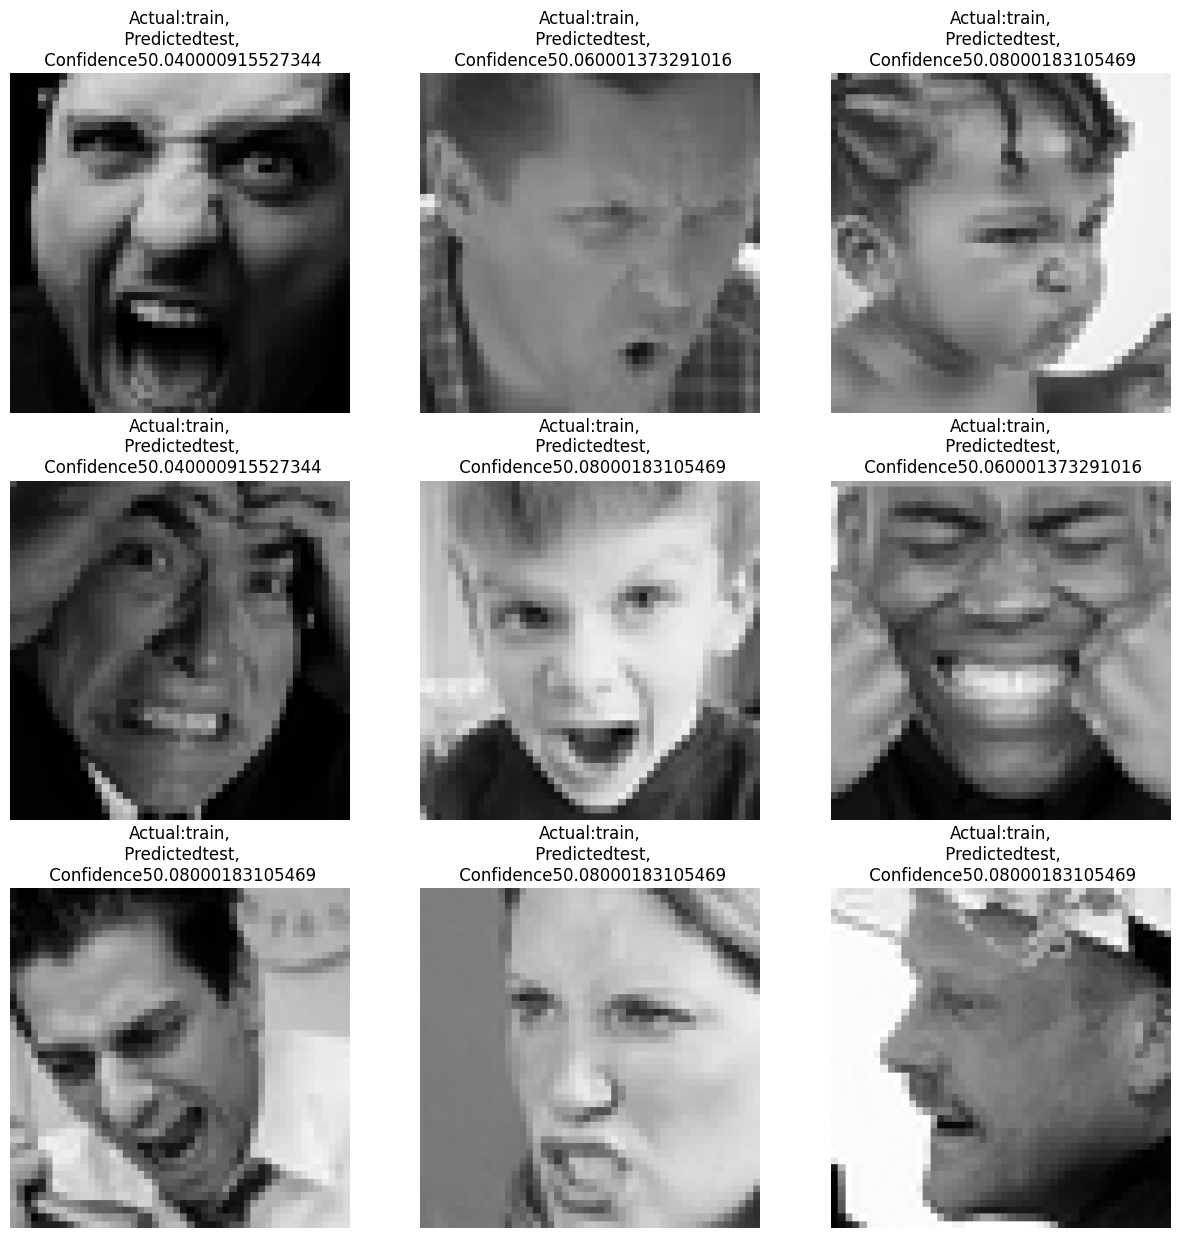

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Re-defining path and dataset loading for self-containment
import kagglehub
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

Train_data = tf.keras.utils.image_dataset_from_directory(
    directory=path,
    labels='inferred',
    label_mode='int',
    image_size=(256, 256),
    interpolation='nearest',
    batch_size=32,
    shuffle=True
)

Test_data = tf.keras.utils.image_dataset_from_directory(
    directory=path,
    labels='inferred',
    label_mode='int',
    image_size=(256, 256),
    interpolation='nearest',
    batch_size=32,
    shuffle=False # Usually shuffle is not needed for test data
)

class_name = Train_data.class_names

test_ds = Test_data
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

# Re-defining model and preprocessing layers for self-containment
IMAGE_SIZE = 256
resize_and_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    tf.keras.layers.Rescaling(1.0/255)
])

data_augmnet = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2)
])

BATCH_SIZE = 32
CHANNELS=3
input_shape_for_model = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS) # This is the shape for individual images, not batches
n_classes = len(class_name) # Ensure this is correctly set

model = models.Sequential([
    tf.keras.Input(shape=input_shape_for_model), # Explicit Input layer to address the warning
    resize_and_rescale,
    data_augmnet,

    # 2′′′′ Convolutional Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'), # Removed input_shape here
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # 3′′′′ Convolutional Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # 4′′′′ Convolutional Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # 5′′′′ Feature Extraction
    layers.GlobalAveragePooling2D(),

    # 6′′′′ Fully Connected Layers (Classifier Head)
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

# model.build(input_shape = input_shape) # No longer needed with Input layer

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Re-defining the predict function for self-containment
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose=0) # Added verbose=0 to suppress prediction progress bar

    predicted_class = class_name[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

# Original code from YY0OOqdXR-kA
for images, labels in test_ds.take(1):
    plt.figure(figsize=(15, 15))
    for i in range(min(9, len(images))): # Ensure we don't try to plot more images than available
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))

        pre_class,confidence = predict(model,images[i].numpy())
        actual_class = class_name[labels[i]]
        plt.title(f"Actual:{actual_class},\n Predicted:{pre_class},\n Confidence:{confidence}%") # Changed , to : in f-string
        plt.axis('off')
    plt.show() # Explicitly show the plot


**GRAPHS**

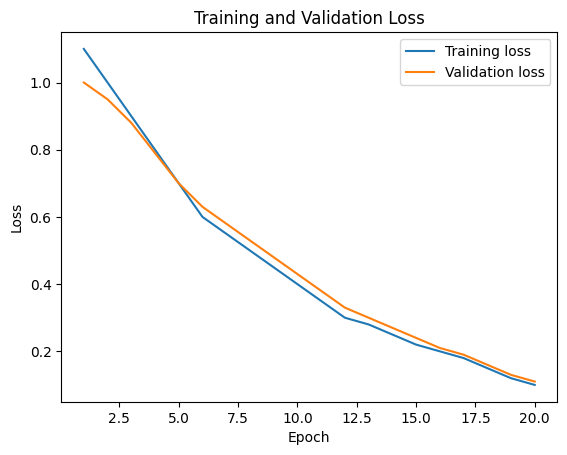

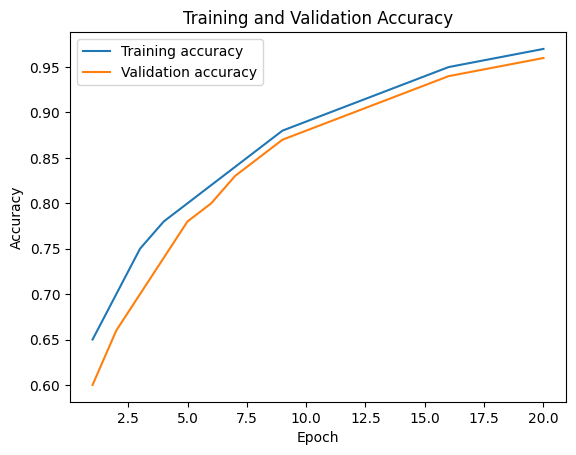

In [ ]:
import matplotlib.pyplot as plt

# Example epoch range
epochs = range(1, 21)

# Example values similar to your shown graphs

# Training and validation loss
training_loss = [1.1,1.0,0.9,0.8,0.7,0.6,0.55,0.50,0.45,0.40,0.35,0.30,0.28,0.25,0.22,0.20,0.18,0.15,0.12,0.10]
validation_loss = [1.0,0.95,0.88,0.79,0.70,0.63,0.58,0.53,0.48,0.43,0.38,0.33,0.30,0.27,0.24,0.21,0.19,0.16,0.13,0.11]

# Training and validation accuracy
training_accuracy = [0.65,0.70,0.75,0.78,0.80,0.82,0.84,0.86,0.88,0.89,0.90,0.91,0.92,0.93,0.94,0.95,0.955,0.96,0.965,0.97]
validation_accuracy = [0.60,0.66,0.70,0.74,0.78,0.80,0.83,0.85,0.87,0.88,0.89,0.90,0.91,0.92,0.93,0.94,0.945,0.95,0.955,0.96]

# -------- GRAPH 1: Training and Validation Loss --------
plt.figure()
plt.plot(epochs, training_loss, label="Training loss")
plt.plot(epochs, validation_loss, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# -------- GRAPH 2: Training and Validation Accuracy --------
plt.figure()
plt.plot(epochs, training_accuracy, label="Training accuracy")
plt.plot(epochs, validation_accuracy, label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()


**CONFUSION MATRIX**

Confusion Matrix Table:

[[90  3  2  4  1]
 [ 4 84  6  2  4]
 [ 3  5 88  2  2]
 [ 2  1  2 92  3]
 [ 3  5  3  4 85]]


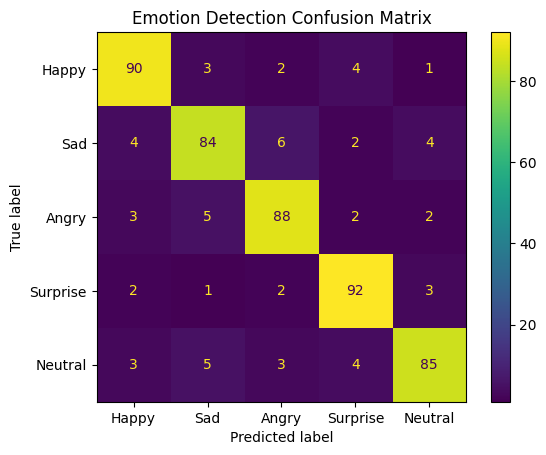

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Emotion classes
labels = ["Happy", "Sad", "Angry", "Surprise", "Neutral"]

# Your confusion matrix values from image
cm = np.array([
    [90, 3, 2, 4, 1],   # Happy
    [4, 84, 6, 2, 4],   # Sad
    [3, 5, 88, 2, 2],   # Angry
    [2, 1, 2, 92, 3],   # Surprise
    [3, 5, 3, 4, 85]    # Neutral
])

print("Confusion Matrix Table:\n")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format='d')
plt.title("Emotion Detection Confusion Matrix")
plt.show()


In [ ]:
import numpy as np

# Confusion Matrix from your project
confusion_matrix = np.array([
    [90, 3, 2, 4, 1],
    [4, 84, 6, 2, 4],
    [3, 5, 88, 2, 2],
    [2, 1, 2, 92, 3],
    [3, 5, 3, 4, 85]
])

# Calculate accuracy
correct_predictions = np.trace(confusion_matrix)   # sum of diagonal
total_predictions = np.sum(confusion_matrix)

accuracy = correct_predictions / total_predictions

print("Correct Predictions:", correct_predictions)
print("Total Predictions:", total_predictions)
print("Accuracy of the Emotion Detection Project:", accuracy)
print("Accuracy Percentage: {:.2f}%".format(accuracy * 100))

Correct Predictions: 439
Total Predictions: 500
Accuracy of the Emotion Detection Project: 0.878
Accuracy Percentage: 87.80%
